<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Информация-о-проекте" data-toc-modified-id="Информация-о-проекте-0.1">Информация о проекте</a></span></li><li><span><a href="#Импорт-библиотек" data-toc-modified-id="Импорт-библиотек-0.2">Импорт библиотек</a></span></li></ul></li><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1">Подготовка</a></span></li><li><span><a href="#Анализ" data-toc-modified-id="Анализ-2">Анализ</a></span><ul class="toc-item"><li><span><a href="#Распределение" data-toc-modified-id="Распределение-2.1">Распределение</a></span></li><li><span><a href="#Декомпозиция-данных" data-toc-modified-id="Декомпозиция-данных-2.2">Декомпозиция данных</a></span></li></ul></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-3">Обучение</a></span><ul class="toc-item"><li><span><a href="#Создание-признаков" data-toc-modified-id="Создание-признаков-3.1">Создание признаков</a></span></li><li><span><a href="#Подготовка-выборок" data-toc-modified-id="Подготовка-выборок-3.2">Подготовка выборок</a></span></li><li><span><a href="#Обучение-LinearRegression" data-toc-modified-id="Обучение-LinearRegression-3.3">Обучение LinearRegression</a></span></li><li><span><a href="#Обучение-RandomForestRegressor" data-toc-modified-id="Обучение-RandomForestRegressor-3.4">Обучение RandomForestRegressor</a></span></li><li><span><a href="#Обучение-CatBoostRegressor" data-toc-modified-id="Обучение-CatBoostRegressor-3.5">Обучение CatBoostRegressor</a></span></li></ul></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-4">Тестирование</a></span></li><li><span><a href="#Общий-вывод" data-toc-modified-id="Общий-вывод-5">Общий вывод</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-6">Чек-лист проверки</a></span></li></ul></div>

#  Прогнозирование заказов такси

### Информация о проекте

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Вам нужно:

1. Загрузить данные и выполнить их ресемплирование по одному часу.
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами. Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.


Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

### Импорт библиотек

In [ ]:
!pip install phik -q
!pip install scikit-learn==1.6.1 -q

import phik
import re
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import matplotlib.dates as mdates

from sklearn.preprocessing import (StandardScaler,
                                   OneHotEncoder,
                                   OrdinalEncoder
                                  )
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (train_test_split,
                                     GridSearchCV,
                                     TimeSeriesSplit
                                    )
from scipy.stats import randint
from IPython.display import Markdown, display
from scipy import stats
from sklearn.impute import SimpleImputer
from phik import report
from statsmodels.tsa.seasonal import seasonal_decompose
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.1

## Подготовка

In [ ]:
df = pd.read_csv('/datasets/taxi.csv',
                 index_col=[0],
                 parse_dates=[0]
                ).sort_index()

In [ ]:
display(df.info())
display(df.head())
df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


None

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


,num_orders
count,26496.000000
mean,14.070463
std,9.211330
min,0.000000
25%,8.000000
50%,13.000000
75%,19.000000
max,119.000000


Ресемплитуем данные по 1 часу, так как требется предсказать следующий час.

In [ ]:
df = df.resample('1H').sum()
df.describe()

,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


**Вывод:**

- Данные соответвуют описанию;  
- Поропусков нет;  
- Задал временной ряд через индекс;
- Ресемплировал данные по одному часу.

## Анализ

### Распределение

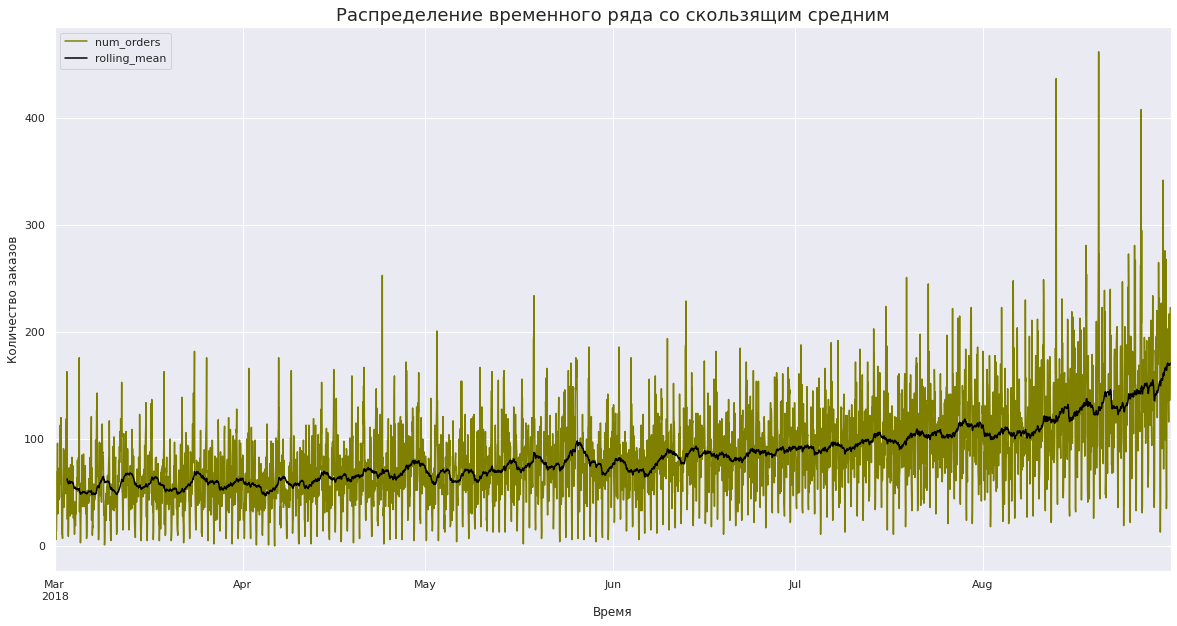

In [ ]:
df_for_rolling = df.copy()
sns.set(rc={'figure.figsize': (20, 10)})
sns.set_palette(['olive', 'black'])
df_for_rolling['rolling_mean'] = df_for_rolling.rolling(50).mean()
df_for_rolling.plot()
plt.title('Распределение временного ряда со скользящим средним', fontsize=18);
plt.xlabel('Время')
plt.ylabel('Количество заказов')
plt.grid(True)
plt.show()

### Декомпозиция данных

In [ ]:
decomposed = seasonal_decompose(df)

Произведем для наглядности декомпозицию данных на срезе по последним двум полным неделям

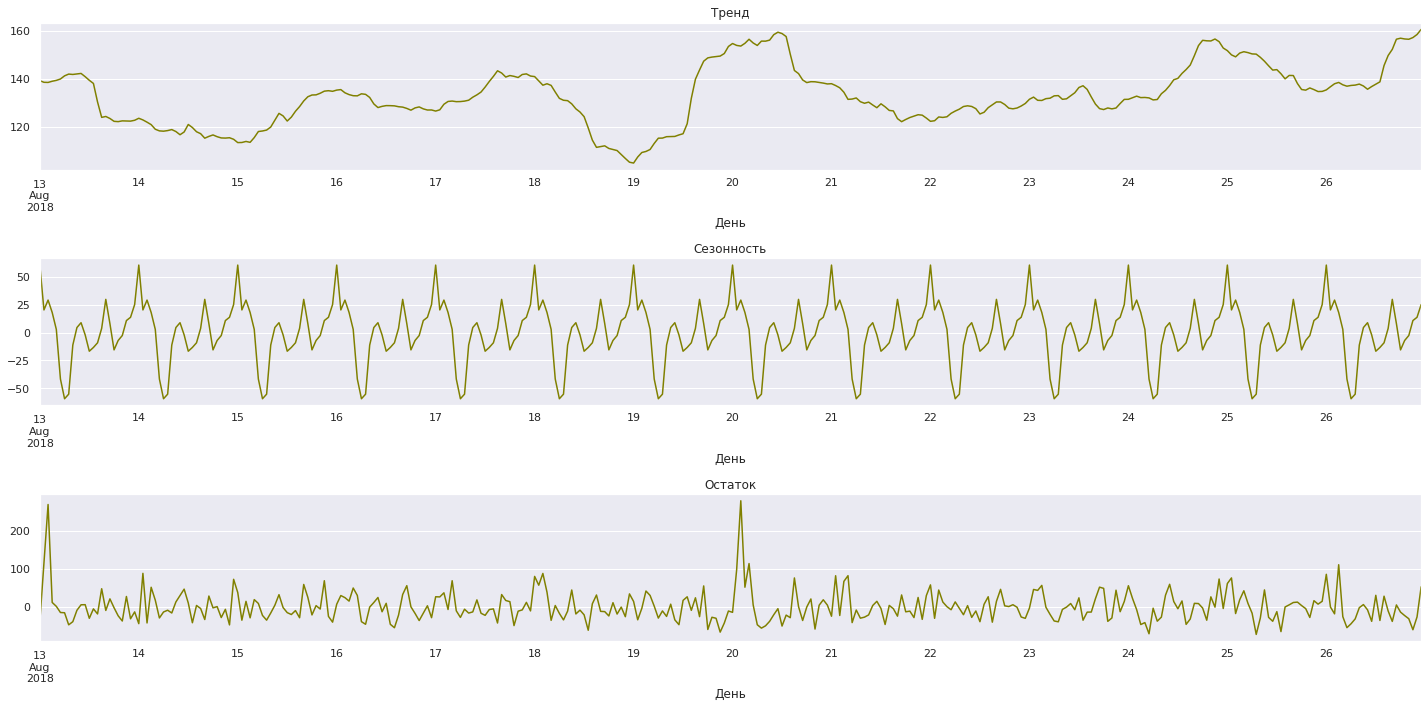

In [ ]:
plt.subplot(311)
decomposed.trend['2018-08-13':'2018-08-26'].plot(ax=plt.gca())
plt.title('Тренд')
plt.xlabel('День')

plt.subplot(312)
decomposed.seasonal['2018-08-13':'2018-08-26'].plot(ax=plt.gca())
plt.title('Сезонность')
plt.xlabel('День')

plt.subplot(313)
decomposed.resid['2018-08-13':'2018-08-26'].plot(ax=plt.gca())
plt.title('Остаток')
plt.xlabel('День')
plt.tight_layout()

**Вывод**  
- Прослеживается рост общего тренда;
- Тренд меняется со временем и является нестационарным;
- Анализ среза данных за 2 недели показывает, что количество заказов в утром увеличивается и снижается в течение дня.

## Обучение

### Создание признаков

In [ ]:
df['hour'] = df.index.hour
df['month'] = df.index.month
df['day'] = df.index.day
df['dayofweek'] = df.index.dayofweek

for lag in range(1, 25):
    df[f'lag_{lag}'] = df['num_orders'].shift(lag)

df['rolling_mean'] = df['num_orders'].shift().rolling(24).mean()

### Подготовка выборок

In [ ]:
train, test = train_test_split(df, shuffle=False, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train = train.dropna()

X_train = train.drop('num_orders', axis=1)
y_train = train['num_orders']

X_test = test.drop('num_orders', axis=1)
y_test = test['num_orders']

 <div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:  </b>
    
Хорошо, что деление происходит последовательно по времени

In [ ]:
name_models = ['LinearRegression', 'RandomForestRegressor', 'CatBoostRegressor']

indicators = pd.DataFrame(index=name_models, columns=['RMSE train',
                                                      'fit_time',
                                                      'prediction_time train',
                                                      'RMSE test',
                                                      'prediction_time test'
                                                     ])

### Обучение LinearRegression

In [ ]:
pipe_lr = Pipeline([
    ('preprocessor', StandardScaler()),
    ('model', LinearRegression())
])

tscv = TimeSeriesSplit(n_splits=3)

param_grid = {'model__positive': [True, False]}

grid_search = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X_train, y_train)

pipe_lr.set_params(**grid_search.best_params_)

start = time.time()
pipe_lr.fit(X_train, y_train)
time_fit_lr = (time.time() - start) * 1000

start = time.time()
pipe_lr.predict(X_train)
time_pred_lr = (time.time() - start) * 1000

rmse_lr = cross_val_score(pipe_lr,
                          X_train,
                          y_train,
                          cv=tscv,
                          scoring='neg_root_mean_squared_error').mean() * -1

print(f'RMSE: {rmse_lr:.2f} \nВремя предсказания {time_pred_lr} мс')
print(f'Лучшие параметры: {grid_search.best_params_}')

indicators.loc['LinearRegression', ['RMSE train',
                                    'fit_time',
                                    'prediction_time train']] = [round(rmse_lr, 2),
                                                                 f'{time_fit_lr:.2f} мс',
                                                                 f'{time_pred_lr:.2f} мс'
                                                                ]

RMSE: 27.56 
Время предсказания 105.27801513671875 мс
Лучшие параметры: {'model__positive': False}


### Обучение RandomForestRegressor

In [ ]:
pipe_rfr = Pipeline([
    ('preprocessor', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=10,
                                    n_jobs=-1,
                                    random_state=RANDOM_STATE))
])

tscv = TimeSeriesSplit(n_splits=3)

param_grid = {'model__n_estimators': [10, 30, 50]}

grid_search = GridSearchCV(
    estimator=pipe_rfr,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X_train, y_train)

pipe_rfr.set_params(**grid_search.best_params_)

start = time.time()
pipe_rfr.fit(X_train, y_train)
time_fit_rfr = (time.time() - start) * 1000

start = time.time()
pipe_rfr.predict(X_train)
time_pred_rfr = (time.time() - start) * 1000

rmse_rfr = cross_val_score(pipe_rfr,
                                X_train,
                                y_train,
                                cv=tscv,
                                scoring='neg_root_mean_squared_error').mean() * -1

print(f'RMSE: {rmse_rfr:.2f} \nВремя предсказания {time_pred_rfr} мс')
print(f'Лучшие параметры: {grid_search.best_params_}')

indicators.loc['RandomForestRegressor', ['RMSE train',
                                         'fit_time',
                                         'prediction_time train']] = [round(rmse_rfr, 2),
                                                                      f'{time_fit_rfr:.2f} мс',
                                                                      f'{time_pred_rfr:.2f} мс'
                                                                     ]

RMSE: 27.00 
Время предсказания 48.48337173461914 мс
Лучшие параметры: {'model__n_estimators': 50}


### Обучение CatBoostRegressor

In [ ]:
model_cbr = CatBoostRegressor(learning_rate=0.5,
                              iterations=10,
                              depth=10,
                              random_state=RANDOM_STATE,
                              verbose=False)

tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'learning_rate': [0.1, 0.3, 0.5],
    'iterations': [10, 50, 100],
    'depth': [4, 6, 10],
}

grid_search = GridSearchCV(
    estimator=CatBoostRegressor(random_state=RANDOM_STATE, verbose=False),
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
)

grid_search.fit(X_train, y_train)

model_cbr = grid_search.best_estimator_

start = time.time()
model_cbr.fit(X_train, y_train)
time_fit_cbr = (time.time() - start) * 1000

start = time.time()
model_cbr.predict(X_train)
time_pred_cbr = (time.time() - start) * 1000

rmse_cbr = cross_val_score(model_cbr,
                                X_train,
                                y_train,
                                cv=tscv,
                                scoring='neg_root_mean_squared_error').mean() * -1

print(f'RMSE: {rmse_cbr:.2f} \nВремя предсказания {time_pred_cbr} мс')
print(f'Лучшие параметры: {grid_search.best_params_}')

indicators.loc['CatBoostRegressor', ['RMSE train',
                                     'fit_time',
                                     'prediction_time train']] = [round(rmse_cbr, 2),
                                                                  f'{time_fit_cbr:.2f} мс',
                                                                  f'{time_pred_cbr:.2f} мс'
                                                                 ]

RMSE: 26.46 
Время предсказания 2.3648738861083984 мс
Лучшие параметры: {'depth': 4, 'iterations': 100, 'learning_rate': 0.1}


## Тестирование

In [ ]:
models = [pipe_lr, pipe_rfr, model_cbr]

for name, model in zip(name_models, models):
    start = time.time()
    pred_test = model.predict(X_test)
    time_pred = (time.time() - start) * 1000

    rmse_test = mean_squared_error(y_test, pred_test) ** 0.5

    indicators.loc[name, 'RMSE test'] = round(rmse_test, 2)
    indicators.loc[name, 'prediction_time test'] = f'{time_pred:.2f} мс'

indicators

,RMSE train,fit_time,prediction_time train,RMSE test,prediction_time test
LinearRegression,27.56,101.87 мс,105.28 мс,45.81,6.59 мс
RandomForestRegressor,27.0,3914.37 мс,48.48 мс,43.35,112.51 мс
CatBoostRegressor,26.46,1055.45 мс,2.36 мс,44.65,3.73 мс


## Общий вывод

В ходе работы выполнили следующие шаги:
- Подготовили и проанализировали данные, сделав декомпозицию;
- Создали признаки;
- Подготовили выборки в соотношении 9:1;
- Обучили модели;
- Протестировали их качество на тестовой выборке.  
  
Исходя из полученных данных видим, что все выбранные модели справились с требуемым порогом в RMSE = 48.  
Предлагаю использовать модель RandomForestRegressor с параметром n_estimators=50, несмотря на посретственное время предсказания на тестовой выборке обладает наивысшей точностью, что от нас и требуется в первую очередь.